<a href="https://colab.research.google.com/github/Ayush-Gole8/DeepLearning/blob/main/23102A0005_DL_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fetching AAPL market data...
Dataset Split -> Train: 1560 days | Test: 391 days

--- Training LSTM Architecture ---
Epoch 1/100


/tmp/ipykernel_605/2590371109.py:40: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(CONFIG["TICKER"], start=CONFIG["START_DATE"], end=CONFIG["END_DATE"], progress=False)


49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0217 - val_loss: 0.0028
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0030 - val_loss: 0.0053
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0023 - val_loss: 0.0070
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0021 - val_loss: 0.0054
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0019 - val_loss: 0.0051
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - val_loss: 0.0040
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

--- Training GRU Architecture ---
Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0193 - val_loss: 0.0095
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0030 - val_loss: 0.0034
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0024 - val_loss: 0.0017
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0020 - val_loss: 0.0022
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━

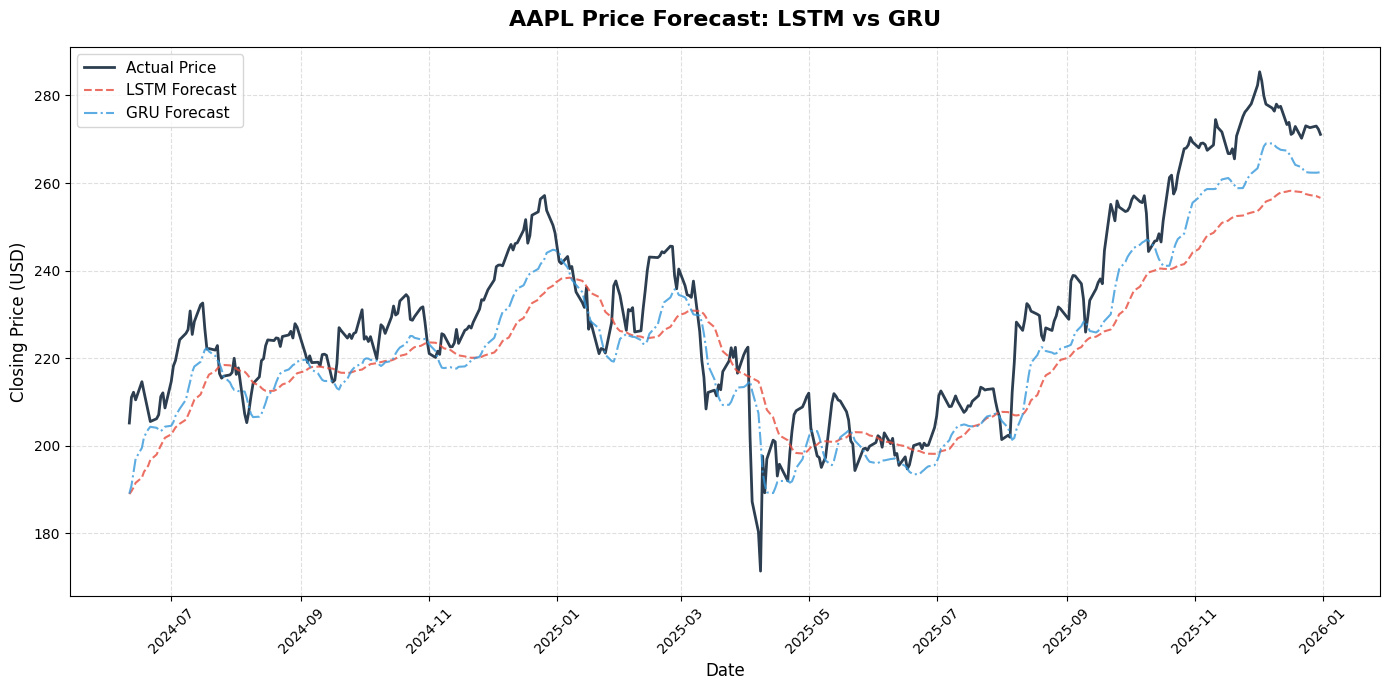

In [5]:
# ==========================================
# TIME-SERIES FORECASTING: STOCK PREDICTION
# LSTM vs GRU COMPARISON
# ==========================================

#!pip install yfinance -q

import math
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# HYPERPARAMETER CONFIGURATION
# ==========================================
CONFIG = {
    "TICKER": "AAPL",
    "START_DATE": "2018-01-01",
    "END_DATE": "2026-01-01",
    "SEQ_LENGTH": 60,
    "TRAIN_SPLIT": 0.8,
    "EPOCHS": 100,
    "BATCH_SIZE": 32,
    "DROPOUT_RATE": 0.3,
    "UNITS": 50
}

# ==========================================
# 1. FETCH & PREPARE DATA
# ==========================================
print(f"Fetching {CONFIG['TICKER']} market data...")
df = yf.download(CONFIG["TICKER"], start=CONFIG["START_DATE"], end=CONFIG["END_DATE"], progress=False)

# Safely extract 1D Close prices array
data = df['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# ==========================================
# 2. CREATE SLIDING WINDOW SEQUENCES
# ==========================================
def create_sequences(dataset, seq_length):
    X, y = [], []
    for i in range(seq_length, len(dataset)):
        X.append(dataset[i-seq_length:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled_data, CONFIG["SEQ_LENGTH"])
X_all = np.reshape(X_all, (X_all.shape[0], X_all.shape[1], 1))

train_size = int(len(X_all) * CONFIG["TRAIN_SPLIT"])
X_train, y_train = X_all[:train_size], y_all[:train_size]
X_test, y_test = X_all[train_size:], y_all[train_size:]

print(f"Dataset Split -> Train: {len(X_train)} days | Test: {len(X_test)} days\n")

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# ==========================================
# 3. MODEL ARCHITECTURE BUILDER
# ==========================================
def build_model(model_type):
    model = Sequential()
    model.add(Input(shape=(CONFIG["SEQ_LENGTH"], 1)))

    if model_type == 'LSTM':
        model.add(LSTM(CONFIG["UNITS"], return_sequences=True))
        model.add(Dropout(CONFIG["DROPOUT_RATE"]))
        model.add(LSTM(CONFIG["UNITS"], return_sequences=False))
    elif model_type == 'GRU':
        model.add(GRU(CONFIG["UNITS"], return_sequences=True))
        model.add(Dropout(CONFIG["DROPOUT_RATE"]))
        model.add(GRU(CONFIG["UNITS"], return_sequences=False))

    model.add(Dropout(CONFIG["DROPOUT_RATE"]))
    model.add(Dense(25, activation='relu'))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# ==========================================
# 4. TRAIN MODELS
# ==========================================
print("--- Training LSTM Architecture ---")
lstm_model = build_model('LSTM')
lstm_history = lstm_model.fit(
    X_train, y_train, batch_size=CONFIG["BATCH_SIZE"], epochs=CONFIG["EPOCHS"],
    validation_data=(X_test, y_test), callbacks=[early_stop], verbose=1
)

print("\n--- Training GRU Architecture ---")
gru_model = build_model('GRU')
gru_history = gru_model.fit(
    X_train, y_train, batch_size=CONFIG["BATCH_SIZE"], epochs=CONFIG["EPOCHS"],
    validation_data=(X_test, y_test), callbacks=[early_stop], verbose=1
)

# ==========================================
# 5. EVALUATE & INVERSE TRANSFORM
# ==========================================
lstm_preds = scaler.inverse_transform(lstm_model.predict(X_test, verbose=0))
gru_preds = scaler.inverse_transform(gru_model.predict(X_test, verbose=0))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

lstm_rmse = math.sqrt(mean_squared_error(y_test_inv, lstm_preds))
lstm_mae = mean_absolute_error(y_test_inv, lstm_preds)

gru_rmse = math.sqrt(mean_squared_error(y_test_inv, gru_preds))
gru_mae = mean_absolute_error(y_test_inv, gru_preds)

print("\n==========================================")
print("FINAL EVALUATION METRICS (USD)")
print("==========================================")
print(f"LSTM Error -> RMSE: ${lstm_rmse:.2f} | MAE: ${lstm_mae:.2f}")
print(f"GRU  Error -> RMSE: ${gru_rmse:.2f}  | MAE: ${gru_mae:.2f}")

# ==========================================
# 6. VISUALIZATION
# ==========================================
test_dates = df.index[CONFIG["SEQ_LENGTH"]:][train_size:]

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test_inv, color='#2c3e50', label='Actual Price', linewidth=2)
plt.plot(test_dates, lstm_preds, color='#e74c3c', label='LSTM Forecast', alpha=0.8, linestyle='--')
plt.plot(test_dates, gru_preds, color='#3498db', label='GRU Forecast', alpha=0.8, linestyle='-.')

plt.title(f"{CONFIG['TICKER']} Price Forecast: LSTM vs GRU", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Closing Price (USD)", fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()

image_path = f"{CONFIG['TICKER']}_forecast_comparison.png"
plt.savefig(image_path, dpi=300)
print(f"\n✅ Plot saved to Colab workspace: {image_path}")
plt.show()